### Import Libraries

In [1]:
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

# Feature Engineering
from sklearn.preprocessing import LabelEncoder

# Balance target data
from imblearn.over_sampling import SMOTE 

# Modeling
import joblib
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


### Reading files

In [2]:
customer = pd.read_csv("Dataset\dim_customer.csv")
date = pd.read_csv("Dataset\dim_date.csv")
geography = pd.read_csv("Dataset/dim_geography.csv")
order = pd.read_csv("Dataset\dim_order.csv")
product = pd.read_csv("Dataset\dim_product.csv")
returned = pd.read_csv("Dataset\dim_returned.csv")
shipping = pd.read_csv("Dataset\dim_shipping.csv")
fact = pd.read_excel("Dataset/fact_order_detail.xlsx")

### Merging files

In [3]:
# merge with shipping file
merge_df = pd.merge(fact, shipping, 
                    left_on='fact_order_detail[Order ID]',
                    right_on='Order ID',
                    how='left')

# merge with customer file
merge_df = pd.merge(merge_df, customer, 
                    left_on= 'fact_order_detail[Customer ID]',
                    right_on='Customer ID',
                    how='left')

# merge with order file
merge_df = pd.merge(merge_df, order, 
                    left_on= 'fact_order_detail[Order ID]',
                    right_on='Order ID',
                    how='left')

# merge with product file
merge_df = pd.merge(merge_df, product, 
                    left_on= 'fact_order_detail[Product ID]',
                    right_on='Product ID',
                    how='left')

# merge with geography file
geography = geography[['dim_geography[Order ID]', 'dim_geography[Country]', 'dim_geography[Region]', 'dim_geography[City]']]
merge_df = pd.merge(merge_df, geography, 
                    left_on=  'fact_order_detail[Order ID]',
                    right_on= 'dim_geography[Order ID]',
                    how='left')

In [4]:
# delete some columns
merge_df.drop(['Order ID_x', 'Count of Shipping ID', 'Customer ID_x', 
               'Customer Name', 'Customer ID_y', 'Order ID_y', 
               'Product ID', 'Product Name', 'dim_geography[Order ID]'], axis=1, inplace=True)

# rename columns
merge_df.columns = ['Row ID', 'Order ID',
                'Product ID', 'Sales',
                'Quantity', 'Discount',
                'Profit', 'Shipping Cost',
                'Customer ID', 'Order Date ID',
                'Ship Date ID','Order Date',
                'Ship Date', 'Ship Mode','Segment', 
                'Market', 'Category', 'Sub-Category','Country', 'Region', 'City']

# keeping the required columns and correcting the column order
merge_df = merge_df[['Order ID', 'Product ID', 'Customer ID', 
                    'Sales', 'Quantity', 'Discount','Profit', 
                    'Shipping Cost', 'Ship Mode', 'Country', 'Region','City',
                    'Segment','Market', 'Category', 'Sub-Category',
                    'Order Date', 'Ship Date']]

# changing the format of the date column - delete day and time
merge_df['Order Date'] = pd.to_datetime(merge_df['Order Date']).dt.date
merge_df['Ship Date'] = pd.to_datetime(merge_df['Ship Date']).dt.date

In [5]:
# convert to Excel
excel_file = merge_df.to_excel('Product_Sales_Info.xlsx', index=False)

# read dataset
df = pd.read_excel('Product_Sales_Info.xlsx')
df.head(3)

,Order ID,Product ID,Customer ID,Sales,Quantity,Discount,Profit,Shipping Cost,Ship Mode,Country,Region,City,Segment,Market,Category,Sub-Category,Order Date,Ship Date
0,MX-2014-139164,OFF-ST-10001590,SF-20200,22.639999,2,0.0,0.0,4.601000,First Class,El Salvador,Central,Antiguo Cuscatlán,Consumer,LATAM,Office Supplies,Storage,2014-09-08,2014-09-11
1,MX-2014-105921,TEC-AC-10004626,ZC-21910,342.079987,2,0.0,0.0,21.712999,Standard Class,El Salvador,Central,San Salvador,Consumer,LATAM,Technology,Accessories,2014-05-28,2014-06-03
2,MX-2013-118402,OFF-BI-10001304,JM-15250,38.880001,2,0.0,0.0,5.923000,Second Class,Mexico,North,Hermosillo,Consumer,LATAM,Office Supplies,Binders,2013-09-19,2013-09-21


### Data Preprocessing

In [6]:
print(f"The dataframe has {df.shape[1]} columns and {df.shape[0]} rows.")

The dataframe has 18 columns and 49670 rows.


In [7]:
print(f"Columns:\n{df.columns}")

Columns:
Index(['Order ID', 'Product ID', 'Customer ID', 'Sales', 'Quantity',
       'Discount', 'Profit', 'Shipping Cost', 'Ship Mode', 'Country', 'Region',
       'City', 'Segment', 'Market', 'Category', 'Sub-Category', 'Order Date',
       'Ship Date'],
      dtype='object')


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49670 entries, 0 to 49669
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       49670 non-null  object        
 1   Product ID     49670 non-null  object        
 2   Customer ID    49670 non-null  object        
 3   Sales          49670 non-null  float64       
 4   Quantity       49670 non-null  int64         
 5   Discount       49670 non-null  float64       
 6   Profit         49670 non-null  float64       
 7   Shipping Cost  49670 non-null  float64       
 8   Ship Mode      49670 non-null  object        
 9   Country        49670 non-null  object        
 10  Region         49670 non-null  object        
 11  City           49670 non-null  object        
 12  Segment        49670 non-null  object        
 13  Market         49670 non-null  object        
 14  Category       49670 non-null  object        
 15  Sub-Category   4967

#### Numerical columns

In [9]:
df[['Sales', 'Quantity','Discount', 'Profit', 'Shipping Cost']].describe()

,Sales,Quantity,Discount,Profit,Shipping Cost
count,49670.000000,49670.000000,49670.000000,49670.000000,49670.000000
mean,243.840355,3.470787,0.143070,28.392264,26.041125
std,485.963091,2.274854,0.212046,172.399520,56.870281
min,0.444000,1.000000,0.000000,-6599.979980,0.002000
25%,30.384001,2.000000,0.000000,0.000000,2.580000
50%,83.970001,3.000000,0.000000,9.154000,7.660000
75%,247.829998,5.000000,0.200000,36.266400,23.968999
max,22638.500000,14.000000,0.850000,8399.980469,933.570007


##### Outlier

In [10]:
# show columns outlier 
def box_plot(dataframe, columns_list, row_number, col_number, title):
    fig , ax = plt.subplots(row_number, col_number, figsize=(8,6))
    fig.suptitle(title, fontsize=15)
    # Draw a boxplot for each column, specifying the title
    for col, ax in zip(columns_list, ax.flatten()):
        sns.boxplot(y=dataframe[col], ax=ax)
        ax.set_title(col)  
        
    plt.tight_layout()
    plt.show()

In [11]:
# replace outlier with IQR
def replace_IQR(dataframe, column):  
    Q1 , Q3 = dataframe[column].quantile(0.25) ,dataframe[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    dataframe[column] = dataframe[column].clip(lower_limit, upper_limit)

    return dataframe

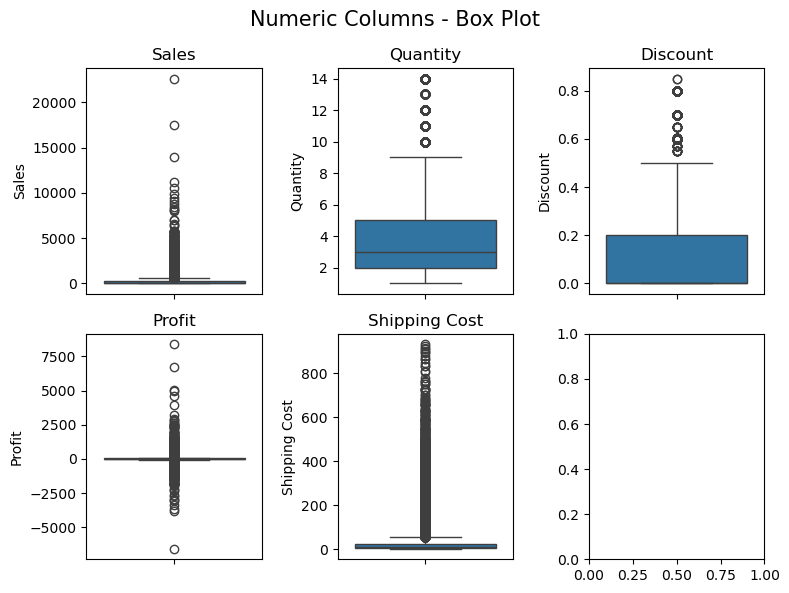

In [12]:
# for checking Outlier
numeric_col_list = ['Sales', 'Quantity','Discount', 'Profit', 'Shipping Cost']   
box_plot(df, numeric_col_list, 2, 3, 'Numeric Columns - Box Plot')

array([[<Axes: xlabel='Sales', ylabel='Sales'>,
        <Axes: xlabel='Discount', ylabel='Sales'>,
        <Axes: xlabel='Profit', ylabel='Sales'>],
       [<Axes: xlabel='Sales', ylabel='Discount'>,
        <Axes: xlabel='Discount', ylabel='Discount'>,
        <Axes: xlabel='Profit', ylabel='Discount'>],
       [<Axes: xlabel='Sales', ylabel='Profit'>,
        <Axes: xlabel='Discount', ylabel='Profit'>,
        <Axes: xlabel='Profit', ylabel='Profit'>]], dtype=object)

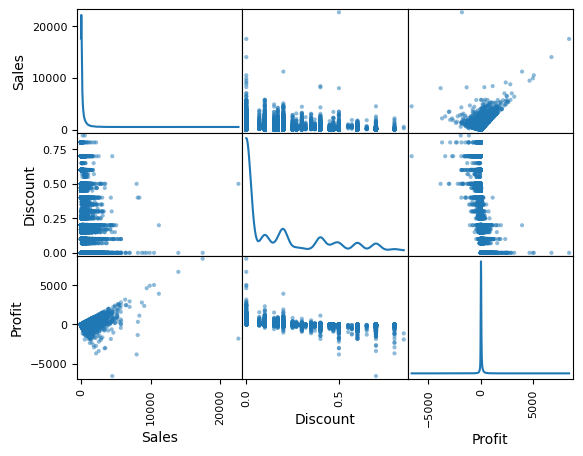

In [13]:
# scatter matrix
pd.plotting.scatter_matrix(df[['Sales','Discount', 'Profit']], diagonal='kde')

#### Category columns

In [14]:
cat_list = ['Ship Mode', 'Segment', 'Market','Category', 'Sub-Category', 
            'Region','City', 'Country']

print("Unique categories for each category:")
for cat in cat_list:
    print(f"{cat} columns: {df[cat].unique()}\n")

Unique categories for each category:
Ship Mode columns: ['First Class' 'Standard Class' 'Second Class' 'Same Day']

Segment columns: ['Consumer' 'Corporate' 'Home Office']

Market columns: ['LATAM' 'APAC' 'EU' 'US' 'EMEA' 'Africa' 'Canada']

Category columns: ['Office Supplies' 'Technology' 'Furniture']

Sub-Category columns: ['Storage' 'Accessories' 'Binders' 'Fasteners' 'Envelopes' 'Art' 'Phones'
 'Chairs' 'Supplies' 'Furnishings' 'Copiers' 'Bookcases' 'Paper' 'Labels'
 'Appliances' 'Machines' 'Tables']

Region columns: ['Central' 'North' 'Caribbean' 'North Asia' 'South' 'Central Asia'
 'Southeast Asia' 'Oceania' 'West' 'East' 'EMEA' 'Africa' 'Canada']

City columns: ['Antiguo Cuscatlán' 'San Salvador' 'Hermosillo' ... 'Isparta' 'Tekirdag'
 'Kastamonu']

Country columns: ['El Salvador' 'Mexico' 'Martinique' 'China' 'Spain' 'India' 'Cuba'
 'Nicaragua' 'United Kingdom' 'France' 'Guatemala' 'Brazil' 'Malaysia'
 'Chile' 'Norway' 'Colombia' 'Ecuador' 'Barbados' 'Italy' 'Germany'
 'Austria

#### Cheking Missing Values and Duplicated Rows

In [15]:
# Missing Values
print("Cheking Missing Values:")
print(f"{df.isnull().any().sum()} Columns")

# Duplicated Rows:
print("\nCheking Duplicated Rows:")
print(f"{len(df[df.duplicated()])} Rows")

Cheking Missing Values:
0 Columns

Cheking Duplicated Rows:
0 Rows


### EDA

In [16]:
'''
Draw a bar chart to compare different shipping mode
'''

# data frame
def count_cat_columns(dataframe, column_name):
    count_df = dataframe.groupby(column_name).size().reset_index(name='Count')
    count_df["Percentage"] = ((count_df['Count'] / count_df['Count'].sum()) * 100).round(2)

    return count_df

# bar pot
def bar_plot(x_axis,y_axis, x_title, y_title):
    bar_plot = px.bar(x = x_axis, 
                  y = y_axis,
                  text_auto=True,
                  labels={'x': x_title,'y': y_title},
               ) 
    
    bar_plot.update_layout(width=600, height=400)
    return(bar_plot)


In [17]:
# count of ship mode 
ship_mode_df = count_cat_columns(df, "Ship Mode")

# Show Bar Plot
bar_plot(ship_mode_df["Ship Mode"],
         ship_mode_df["Percentage"], 
         'Ship Mode', 
         'Percentage')

In [18]:
# count of ship mode vs sum of sales
ship_sales_df = df.groupby('Ship Mode')['Sales'].sum().reset_index(name='Sum Of Sales')
ship_sales_df['Sum Of Sales'] = ship_sales_df['Sum Of Sales'].round().astype(int)
print(ship_sales_df)

# Show Bar Plot
bar_plot(ship_sales_df["Ship Mode"],
         ship_sales_df["Sum Of Sales"], 
         'Ship Mode', 
         'Sum Of Sales')

        Ship Mode  Sum Of Sales
0     First Class       1745405
1        Same Day        631902
2    Second Class       2455339
3  Standard Class       7278904


In [19]:
# count of Segment 
segment_df = count_cat_columns(df, "Segment")

# Show Bar Plot
bar_plot(segment_df["Segment"],
         segment_df["Percentage"], 
         'Segment', 
         'Percentage')

In [20]:
# count of Market 
market_df = count_cat_columns(df, "Market")

# Show Bar Plot
bar_plot(market_df["Market"],
         market_df["Percentage"], 
         'Market', 
         'Percentage')

In [21]:
# count of Category 
category_df = count_cat_columns(df, "Category")

# Show Bar Plot
bar_plot(category_df["Category"],
         category_df["Percentage"], 
         'Category', 
         'Percentage')

In [22]:
# count of Sub Category 
sub_category_df = count_cat_columns(df, "Sub-Category")

# Show Bar Plot
bar_plot(sub_category_df["Sub-Category"],
         sub_category_df["Percentage"], 
         'Sub-Category', 
         'Percentage')

In [23]:
'''
Draw a pivot table to show the classification columns and their impact on the shipping mode.
'''

def pivot_table(index , column):
    pivot = pd.pivot_table(df,
                        index= index,
                        columns= column,
                        aggfunc='size'
    )

    percentage_pivot = (pivot.div(pivot.sum(axis=0), axis=1) * 100).round(2)

    #for col in pivot.columns:
        #pivot[f'{col}%']= ((pivot[col] / pivot[col].sum()) * 100).round(2)

    return percentage_pivot

In [24]:
def pie_chart(df):
    n_rows = int(len(df.columns) / 2)
    fig , axes = plt.subplots(ncols=3, nrows=n_rows, figsize=(20,20))
    colors = sns.color_palette('pastel')

    #for i, col in enumerate(ship_market_pivot.columns):
    for col, ax in zip(df.columns, axes.flatten()):
        ax.pie(
                df[col], 
                labels=df.index, 
                autopct='%1.2f%%', 
                colors=colors
                )
            
        ax.set_title(f"{col}")  

    fig.show()

Segment         Consumer  Corporate  Home Office
Ship Mode                                       
First Class        14.71      14.46        14.29
Same Day            5.56       4.67         5.47
Second Class       19.80      20.76        19.74
Standard Class     59.93      60.11        60.51



C:\Users\ATOUS\AppData\Local\Temp\ipykernel_21668\2877657688.py:17: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



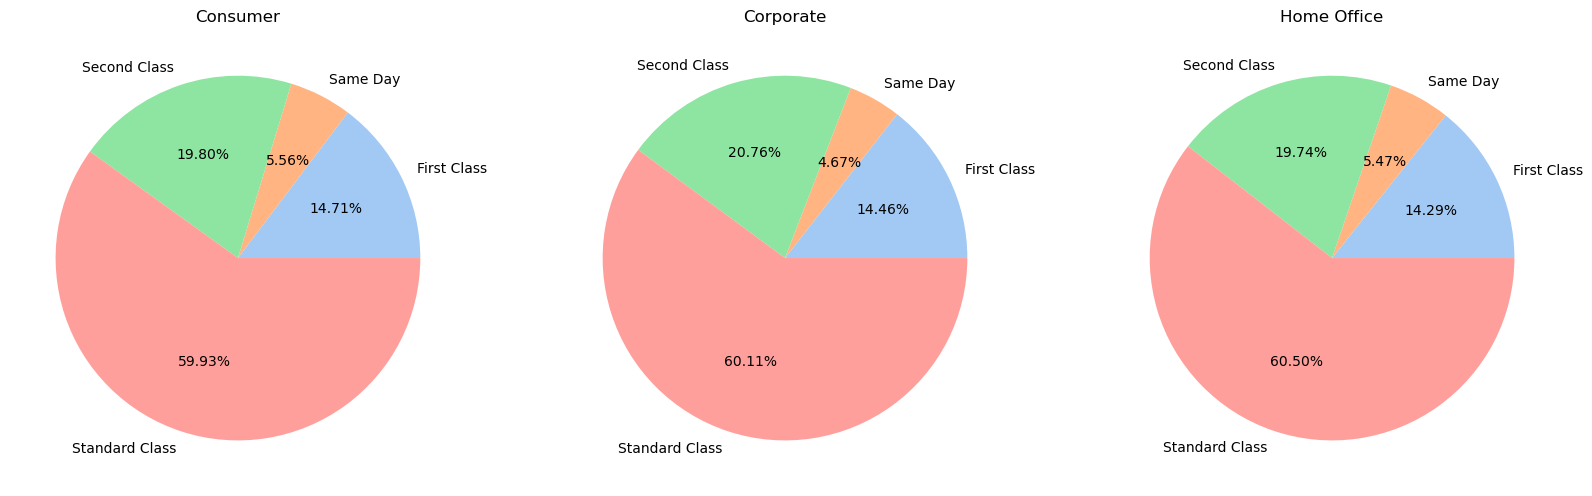

In [25]:
# count of ship mode vs segment
ship_segment_pivot = pivot_table('Ship Mode' , 'Segment')
print(f"{ship_segment_pivot}\n")

pie_chart(ship_segment_pivot)

In [26]:
# count of ship mode vs market
ship_market_pivot = pivot_table('Ship Mode' , 'Market')
ship_market_pivot

#pie_chart(ship_market_pivot)

Market,APAC,Africa,Canada,EMEA,EU,LATAM,US
Ship Mode,,,,,,,
First Class,14.41,14.87,18.62,13.63,14.24,14.37,15.37
Same Day,4.86,5.64,7.45,6.02,5.11,5.09,5.46
Second Class,20.11,21.36,22.87,19.88,19.76,20.40,19.41
Standard Class,60.63,58.14,51.06,60.48,60.89,60.13,59.76


In [27]:
# count of ship mode vs Region
ship_region_pivot = pivot_table('Ship Mode' , 'Region')
ship_region_pivot

#pie_chart(ship_region_pivot)

Region,Africa,Canada,Caribbean,Central,Central Asia,EMEA,East,North,North Asia,Oceania,South,Southeast Asia,West
Ship Mode,,,,,,,,,,,,,
First Class,14.87,18.62,13.59,14.16,12.30,13.63,17.30,14.38,16.47,13.05,14.18,15.76,16.0
Same Day,5.64,7.45,5.07,5.02,3.86,6.02,5.47,5.19,4.53,5.88,5.22,4.63,5.8
Second Class,21.36,22.87,22.11,19.60,21.48,19.88,18.50,19.72,20.10,22.34,20.68,16.71,19.3
Standard Class,58.14,51.06,59.24,61.23,62.35,60.48,58.72,60.70,58.90,58.73,59.92,62.90,58.9


In [28]:
# count of ship mode vs category
ship_cat_pivot = pivot_table('Ship Mode' , 'Category')
ship_cat_pivot

#pie_chart(ship_cat_pivot)

Category,Furniture,Office Supplies,Technology
Ship Mode,,,
First Class,14.52,14.59,14.50
Same Day,5.09,5.39,5.10
Second Class,19.85,20.17,19.99
Standard Class,60.54,59.84,60.41


In [29]:
# count of Sub Category vs category
Category_pivot = pivot_table('Sub-Category' , 'Category').fillna(0)
Category_pivot

Category,Furniture,Office Supplies,Technology
Sub-Category,,,
Accessories,0.00,0.00,30.76
Appliances,0.00,5.53,0.00
Art,0.00,15.45,0.00
Binders,0.00,19.70,0.00
Bookcases,24.17,0.00,0.00
Chairs,34.81,0.00,0.00
Copiers,0.00,0.00,21.79
Envelopes,0.00,7.84,0.00
Fasteners,0.00,7.81,0.00


In [30]:
def sub_category(cat):
    Category = Category_pivot[Category_pivot[cat] != 0]
    
    pie = px.pie(
        Category,
        names= Category[cat].index,
        values= Category[cat].values,
        title=f"{cat}")
    
    pie.update_layout(width=400, height=400,title_x=0.5)

    return pie


sub_category('Technology')
#sub_category('Furniture')
#sub_category('Office Supplies')

## Feature Engineering

In [31]:
feature_df = df.copy()
# required columns
feature_df = feature_df[['Sales', 'Quantity','Discount', 'Profit', 'Ship Mode', 'Region',
                        'Segment', 'Market', 'Category', 'Sub-Category', 'Order Date']]

# add new feature
feature_df['Cat_Sub'] = feature_df["Category"] + '_' + feature_df["Sub-Category"]
feature_df['Region_Market'] = feature_df['Region'] + feature_df['Market']
feature_df['Order_year'] = feature_df['Order Date'].dt.year
feature_df['Order_month'] = feature_df['Order Date'].dt.month
feature_df['Order_day'] = feature_df['Order Date'].dt.day
feature_df['Order_dayofweek'] = feature_df['Order Date'].dt.dayofweek
feature_df["is_weekend"] = feature_df["Order_dayofweek"].isin([5,6]).astype(int)
feature_df['Week_start'] = (feature_df['Order_dayofweek'] == 0).astype(int)
feature_df['Week_end'] = (feature_df['Order_dayofweek'] == 6).astype(int)
feature_df["Month_start"] = feature_df['Order Date'].dt.is_month_start.astype(int)
feature_df['Month_end'] = feature_df['Order Date'].dt.is_month_end.astype(int)
feature_df['Month_mid'] = ((feature_df['Order_day'] > 10) & (feature_df['Order_day'] < 20)).astype(int)

"""
[12,1,2]:  winter(0) 
[3,4,5]:   spring(1)
[6,7,8]:   summer(2)
[9,10,11]: fall(3)
"""
season_map = {12:'winter', 1:'winter', 2:'winter', 
              3:'spring', 4:'spring', 5:'spring', 
              6:'summer', 7:'summer', 8:'summer', 
              9:'fall', 10:'fall', 11:'fall'}
feature_df["Season"] = feature_df["Order_month"].map(season_map)

# delete some columns
feature_df = feature_df.drop(columns=['Order Date', 'Category', 'Sub-Category', 'Region', 'Market'])

feature_df.head(2)

,Sales,Quantity,Discount,Profit,Ship Mode,Segment,Cat_Sub,Region_Market,Order_year,Order_month,Order_day,Order_dayofweek,is_weekend,Week_start,Week_end,Month_start,Month_end,Month_mid,Season
0,22.639999,2,0.0,0.0,First Class,Consumer,Office Supplies_Storage,CentralLATAM,2014,9,8,0,0,1,0,0,0,0,fall
1,342.079987,2,0.0,0.0,Standard Class,Consumer,Technology_Accessories,CentralLATAM,2014,5,28,2,0,0,0,0,0,0,spring


In [32]:
# Missing Values
print("Cheking Missing Values:")
print(f"{feature_df.isnull().any().sum()} Columns")

Cheking Missing Values:
0 Columns


In [33]:
#feature_df[feature_df.duplicated()]

In [34]:
feature_df_excel = feature_df.to_excel('Feature_df.xlsx', index=False)

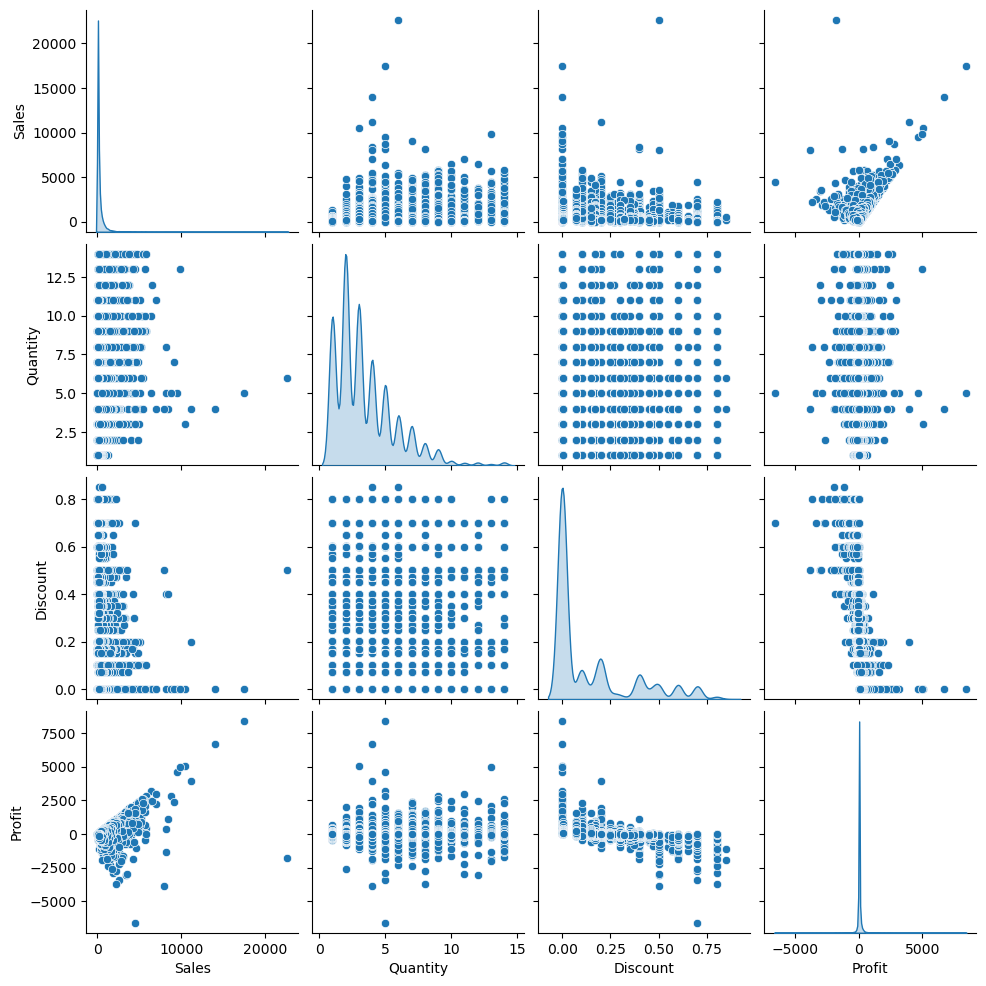

In [35]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

sns.pairplot(feature_df[num_cols], diag_kind='kde')

In [36]:
# Calculating the number of upper and lower outliers with IQR
def outliers_count(data, column):
    Q1 , Q3 = data[column].quantile(0.25) , data[column].quantile(0.75) 
    IQR = Q3 - Q1
    upper , lower = Q3 + 1.5 * IQR , Q1 - 1.5 * IQR 
    count_upper =  (data[column] < lower).sum()
    count_lower =  (data[column] > upper).sum()
    lower_precentage = ((count_lower / len(data[column])) * 100).round(2)
    upper_precentage = ((count_upper / len(data[column])) * 100).round(2)
    
    if count_upper or count_lower > 0 :
        print(f"{column}:\nUpper: {count_upper}, Lower: {count_lower}")
        print(f"Upper%: {upper_precentage}, Lower%: {lower_precentage}\n")

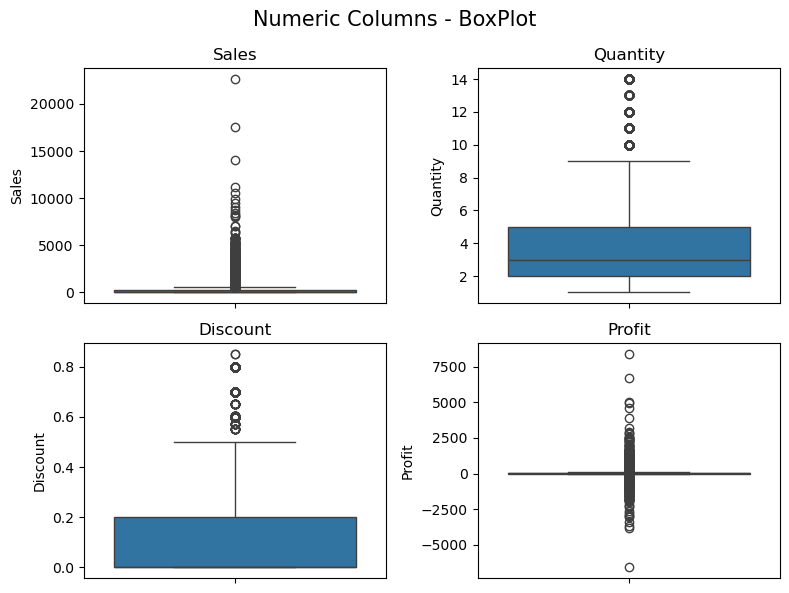

Sales:
Upper: 0, Lower: 5466
Upper%: 0.0, Lower%: 11.0

Quantity:
Upper: 0, Lower: 847
Upper%: 0.0, Lower%: 1.71

Discount:
Upper: 0, Lower: 3981
Upper%: 0.0, Lower%: 8.01

Profit:
Upper: 3419, Lower: 6029
Upper%: 6.88, Lower%: 12.14



In [37]:
box_plot(feature_df, num_cols, 2,2, 'Numeric Columns - BoxPlot')
for col in num_cols:
    outliers_count(feature_df, col)

In [38]:
day_of_week = feature_df.groupby("Order_dayofweek").size().reset_index(name='count')

# rename day of week
mapping_day = {
    0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'
}
day_of_week['Order_dayofweek'] = day_of_week['Order_dayofweek'].map(mapping_day)

# Show Bar Plot
bar_plot(day_of_week['Order_dayofweek'],
         day_of_week['count'], 
         'Day of Week', 
         'Count')

In [39]:
weakend = feature_df.groupby("is_weekend").size().reset_index(name='count')
weakend['is_weekend'] = weakend['is_weekend'].map({0:'No', 1:'Yes'})

# Show Bar Plot
bar_plot(weakend['is_weekend'],
         weakend['count'], 
         'Is Weakend?', 
         'Count')

In [40]:
feature_df.columns

Index(['Sales', 'Quantity', 'Discount', 'Profit', 'Ship Mode', 'Segment',
       'Cat_Sub', 'Region_Market', 'Order_year', 'Order_month', 'Order_day',
       'Order_dayofweek', 'is_weekend', 'Week_start', 'Week_end',
       'Month_start', 'Month_end', 'Month_mid', 'Season'],
      dtype='object')

In [41]:
weak_start = feature_df.groupby("Week_start").size().reset_index(name='count')
weak_start['Week_start'] = weak_start['Week_start'].map({0:'No', 1:'Yes'})

# Show Bar Plot
bar_plot(weak_start['Week_start'],
         weak_start['count'], 
         'Week Start', 
         'Count')

In [42]:
weak_end = feature_df.groupby("Week_end").size().reset_index(name='count')
weak_end['Week_end'] = weak_end['Week_end'].map({0:'No', 1:'Yes'})

# Show Bar Plot
bar_plot(weak_end['Week_end'],
         weak_end['count'], 
         'Week End', 
         'Count')

In [43]:
season  = feature_df.groupby("Season").size().reset_index(name='count')

# Show Bar Plot
bar_plot(season['Season'],
         season['count'], 
         'Season', 
         'Count')

In [44]:
day  = feature_df.groupby("Order_day").size().reset_index(name='count')

# Show Bar Plot
bar_plot(day['Order_day'],
         day['count'], 
         'Order_day', 
         'Count')

In [45]:
month  = feature_df.groupby("Order_month").size().reset_index(name='count')

# Show Bar Plot
bar_plot(month['Order_month'],
         month['count'], 
         'Order Month', 
         'Count')

In [46]:
month_start  = feature_df.groupby("Month_start").size().reset_index(name='count')
month_start['Month_start'] = month_start['Month_start'].map({0:'No', 1:'Yes'})

# Show Bar Plot
bar_plot(month_start['Month_start'],
         month_start['count'], 
         'Month Start', 
         'Count')

In [47]:
month_end  = feature_df.groupby("Month_end").size().reset_index(name='count')
month_end['Month_end'] = month_end['Month_end'].map({0:'No', 1:'Yes'})

# Show Bar Plot
bar_plot(month_end['Month_end'],
         month_end['count'], 
         'Month End', 
         'Count')

In [48]:
month_mid  = feature_df.groupby("Month_mid").size().reset_index(name='count')
month_mid['Month_mid'] = month_mid['Month_mid'].map({0:'No', 1:'Yes'})

# Show Bar Plot
bar_plot(month_mid['Month_mid'],
         month_mid['count'], 
         'Month Mid', 
         'Count')

#### Preprocessing

In [50]:
# X = input , y = Target
X = feature_df.drop('Ship Mode', axis=1)
y = feature_df['Ship Mode']

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size = 0.2, 
    random_state = 42,
    stratify = y
)

test_export = X_test.copy()
test_export['Ship Mode'] = y_test.values
test_export.to_excel('test_set_for_powerbi.xlsx', index=False)

# for numeric columns
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

scaler = RobustScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# for categorical columns
categorical_columns = ['Segment', 'Cat_Sub', 'Region_Market', 'Season']
X_train = pd.get_dummies(X_train, columns=categorical_columns, drop_first=False)
X_test  = pd.get_dummies(X_test,  columns=categorical_columns, drop_first=False)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# encode target
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded  = label_encoder.transform(y_test)

# smote
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train_encoded)

print(f"Before SMOTE:\n{pd.Series(y).value_counts()}\n")
print(f"After SMOTE:\n{pd.Series(y_train_res).value_counts()}")

Before SMOTE:
Ship Mode
Standard Class    29846
Second Class       9972
First Class        7232
Same Day           2620
Name: count, dtype: int64

After SMOTE:
3    23877
2    23877
0    23877
1    23877
Name: count, dtype: int64


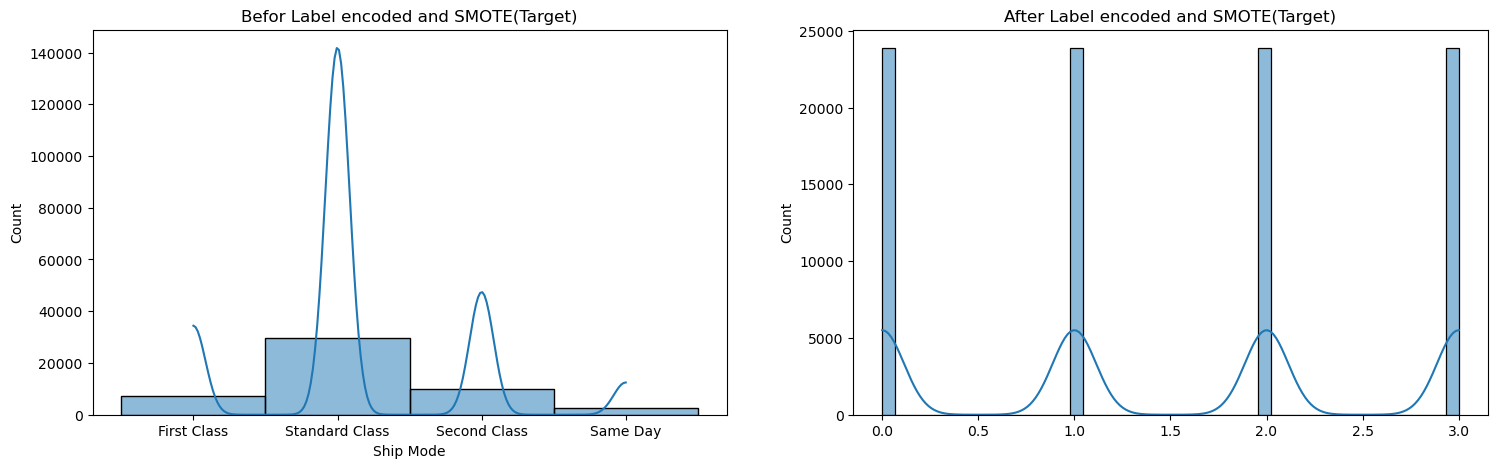

In [51]:
fig , ax = plt.subplots(1,2, figsize=(18,5))

sns.histplot(y , kde=True, ax=ax[0])
ax[0].set_title("Befor Label encoded and SMOTE(Target)")

sns.histplot(y_train_res , kde=True, ax=ax[1])
ax[1].set_title("After Label encoded and SMOTE(Target)")

plt.show()

### Modeling - Random Forest

In [52]:
# Define the Model
random_forest = RandomForestClassifier(
    random_state = 42,
    class_weight = 'balanced'
    )

# Define the parameter grid 
parameter_grid = {
    "n_estimators": [200, 300],          
    "max_depth": [10, 20],               
    "min_samples_split": [2, 5],        
    "min_samples_leaf": [1, 2, 4]        
        } 

# Define the GridSearchCV
grid_search = GridSearchCV(
    estimator = random_forest,          
    param_grid = parameter_grid,
    scoring = "f1_macro",         
    cv = 4,                               
    n_jobs = -1
)

# Fit the model
grid_search.fit(X_train_res, y_train_res)

# Get the best parameters and score
best_model = grid_search.best_estimator_

print("Data length:")
print(f"X Test: {len(X_test)}, X Train:{len(X_train_res)}")
print(f"y Test: {len(y_test)}, y Train:{len(y_train_res)}")

print("\nResult:")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross Validation: {grid_search.best_score_:.4f}")

Data length:
X Test: 9934, X Train:95508
y Test: 9934, y Train:95508

Result:
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best Cross Validation: 0.8099


#### Save Model

In [53]:
joblib.dump(scaler, "scaler.joblib")
joblib.dump(label_encoder, "label_encoder.joblib")
joblib.dump(smote, "smote.joblib")
joblib.dump(X_train_res.columns.to_list(), "fetures.joblib")

['fetures.joblib']

In [54]:
joblib.dump(best_model, "RandomForestModel.joblib")

['RandomForestModel.joblib']

#### Prediction

In [55]:
y_pred_rf = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test_encoded, y_pred_rf)

y_train_pred = best_model.predict(X_train)
train_accuracy = accuracy_score(y_train_encoded, y_train_pred)

print(f'Test Accuracy: {(100 * test_accuracy):.2f}%')
print(f'Train Accuracy: {(100 * train_accuracy):.2f}%')

print("Classification Report:")
print(classification_report(y_test_encoded, y_pred_rf, target_names=label_encoder.classes_))

Test Accuracy: 60.83%
Train Accuracy: 86.48%
Classification Report:
                precision    recall  f1-score   support

   First Class       0.48      0.05      0.09      1446
      Same Day       0.44      0.05      0.09       524
  Second Class       0.53      0.07      0.12      1995
Standard Class       0.61      0.97      0.75      5969

      accuracy                           0.61      9934
     macro avg       0.52      0.28      0.26      9934
  weighted avg       0.57      0.61      0.49      9934



#### Model evaluation

In [56]:
accuracy_rf = accuracy_score(y_test_encoded, y_pred_rf)
precision_rf = precision_score(y_test_encoded, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test_encoded, y_pred_rf, average='weighted')
f1_scor_rf = f1_score(y_test_encoded, y_pred_rf, average='weighted')

print("Random Forest Model:")
print(f'Accuracy:\t {(100 * accuracy_rf):.2f}%')
print(f'Precision:\t {(100 * precision_rf):.2f}%')
print(f'Recall:\t\t {(100 * recall_rf):.2f}%')
print(f'F1 Score:\t {(100 * f1_scor_rf):.2f}%')

Random Forest Model:
Accuracy:	 60.83%
Precision:	 56.80%
Recall:		 60.83%
F1 Score:	 49.35%


#### Importance of features

In [57]:
# ------- Feature Importance ------
feature_importances = best_model.feature_importances_

feature_importances_df = pd.DataFrame({
    'Columns': X_train_res.columns,
    'Importance' : feature_importances
})

top_15_feature = feature_importances_df.sort_values('Importance', ascending=False)[:15]

px.bar(x = top_15_feature['Columns'], 
       y = top_15_feature['Importance'],
       title ='Top 15 Feature Importance in Random Forest',
       labels ={'x': 'Columns', 'y': 'Importance'})

In [58]:
top_10_feature_file = top_15_feature[:10].to_excel('top_10_feature.xlsx', index=False)

In [129]:
#feature_importances_df.sort_values('Importance', ascending=False)

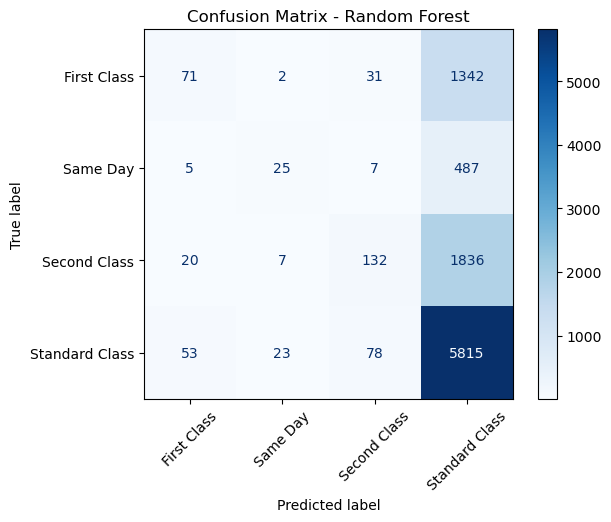

In [59]:
# Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred_rf)
matrix_rf = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
matrix_rf.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - Random Forest")
plt.show()

### Modeling - XGBoost

In [60]:
# create model 
xgb = XGBClassifier(
    objective = "multi:softprob",
    num_class = len(np.unique(y)),
    eval_metric = "mlogloss",
    random_state = 42
)

# Define the parameter grid 
parameter_grid_xgb = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
} 

# Define the GridSearchCV
grid_xgb = GridSearchCV(
    estimator = xgb,
    param_grid = parameter_grid_xgb,
    scoring = "accuracy",
    cv= 4,
    n_jobs= -1,
)

# Fit the model
grid_xgb.fit(X_train_res, y_train_res)

# Get the best parameters and score
best_model_xgb = grid_xgb.best_estimator_

print("Data length:")
print(f"X Test: {len(X_test)}, X Train:{len(X_train_res)}")
print(f"y Test: {len(y_test)}, y Train:{len(y_train_res)}")

print("\nResult:")
print(f"Best Parameters: {grid_xgb.best_params_}")
print(f"Best Cross Validation: {grid_xgb.best_score_:.4f}")

Data length:
X Test: 9934, X Train:95508
y Test: 9934, y Train:95508

Result:
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best Cross Validation: 0.7762


#### Save Model

In [61]:
joblib.dump(best_model_xgb, "XGBoostModel.joblib")

['XGBoostModel.joblib']

#### Prediction

In [62]:
y_pred_xgb = best_model_xgb.predict(X_test)
test_accuracy_xgb = accuracy_score(y_test_encoded, y_pred_xgb)

y_train_pred_xgb = best_model_xgb.predict(X_train)
train_accuracy_xgb = accuracy_score(y_train_encoded, y_train_pred_xgb) #y_train_pred_xgb

print(f'Test Accuracy: {(100 * test_accuracy_xgb):.2f}%')
print(f'Train Accuracy: {(100 * train_accuracy_xgb):.2f}%')

print("Classification Report:")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=label_encoder.classes_))

Test Accuracy: 60.60%
Train Accuracy: 68.56%
Classification Report:
                precision    recall  f1-score   support

   First Class       0.54      0.05      0.09      1446
      Same Day       0.83      0.03      0.06       524
  Second Class       0.48      0.05      0.10      1995
Standard Class       0.61      0.98      0.75      5969

      accuracy                           0.61      9934
     macro avg       0.62      0.28      0.25      9934
  weighted avg       0.58      0.61      0.49      9934



#### Model evaluation

In [63]:
accuracy_xgb = accuracy_score(y_test_encoded, y_pred_xgb)
precision_xgb = precision_score(y_test_encoded, y_pred_xgb, average='weighted')
recall_xgb = recall_score(y_test_encoded, y_pred_xgb, average='weighted')
f1_scor_xgb = f1_score(y_test_encoded, y_pred_xgb, average='weighted')

print("XGBooat Model:")
print(f'Accuracy:\t {(100 * accuracy_xgb):.2f}%')
print(f'Precision:\t {(100 * precision_xgb):.2f}%')
print(f'Recall:\t\t {(100 * recall_xgb):.2f}%')
print(f'F1 Score:\t {(100 * f1_scor_xgb):.2f}%')

XGBooat Model:
Accuracy:	 60.60%
Precision:	 58.50%
Recall:		 60.60%
F1 Score:	 48.58%


#### Importance of features

<Figure size 1000x800 with 0 Axes>

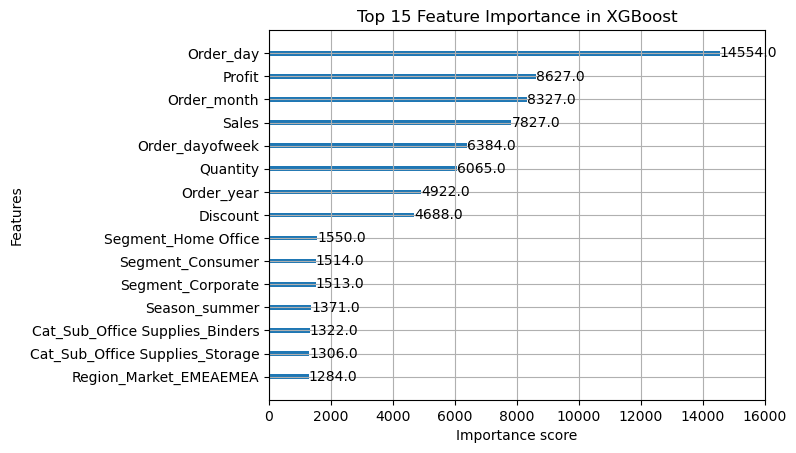

In [64]:
plt.figure(figsize=(10, 8))
plot_importance(best_model_xgb, max_num_features=15)
plt.title('Top 15 Feature Importance in XGBoost')
plt.show()

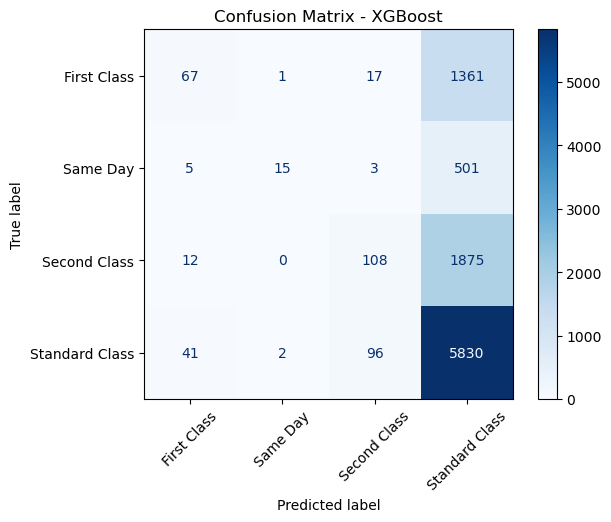

In [65]:
# Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred_xgb)
martix_xgb = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
martix_xgb.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - XGBoost")
plt.show()

#### Create Result DataFrame

In [66]:
data = {
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_rf, accuracy_xgb],
    'Precision': [precision_rf, precision_xgb],
    'Recall': [recall_rf, recall_xgb],
    'F1 Score': [f1_scor_rf, f1_scor_xgb]
}

df_results = pd.DataFrame(data)
excel_result_file = df_results.to_excel('Result_Models.xlsx', index=False)
df_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.608315,0.567956,0.608315,0.493467
1,XGBoost,0.606000,0.584963,0.606000,0.485843
